In [1]:
### Problem Statement
# Develop a Machine Learning model to detect fraudulent behavior in electricity and gas consumption,
# leveraging consumption patterns and anomalies.

In [2]:
### Objectives
# 1. Preprocess and analyze the dataset.
# 2. Create meaningful data visualizations.
# 3. Develop a predictive model with high accuracy (>90%).
# 4. Evaluate the model using appropriate metrics.

In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [4]:
# Step 2: Load Dataset
data = pd.read_csv(r"C:\Users\Vishal Rajput\OneDrive\Desktop\Fraud-Detection-Project\Fraud_Detection_Consumption_1968_to_2024.csv")  # Adjust to your dataset's path
print(data.head())
print(data.info())

   UserID  Consumption    UsageType   TariffPlan Location  \
0       1        86.66  electricity   Commercial  Chicago   
1       2       174.58  electricity  Residential  Chicago   
2       3       196.68  electricity   Commercial  Houston   
3       4       228.18  electricity   Commercial  Seattle   
4       5       169.94          gas  Residential   Boston   

   AverageDailyConsumption TimeOfDay MeterID MeterStatus PaymentHistory  \
0                   358.12      peak  M-2794      Normal           Late   
1                    65.13      peak  M-3306      Normal           Late   
2                   241.98      peak  M-2447    Tampered           Late   
3                   224.32      peak  M-2697    Tampered        On-Time   
4                   301.68      peak  M-1536    Tampered        On-Time   

   FraudReported  
0              0  
1              1  
2              1  
3              1  
4              1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 t

In [5]:
# Encode categorical columns
label_encoders = {}
categorical_cols = ['UsageType', 'TariffPlan', 'Location', 'TimeOfDay', 'MeterStatus', 'PaymentHistory']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le


In [6]:
# Separate features (X) and target variable (y)
X = data.drop(columns=['UserID', 'MeterID', 'FraudReported'])
y = data['FraudReported']


In [7]:
y.to_csv('New_data.csv')

In [8]:
import os
os.getcwd()

'C:\\Users\\Vishal Rajput\\OneDrive\\Desktop\\Fraud-Detection-Project'

In [9]:

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


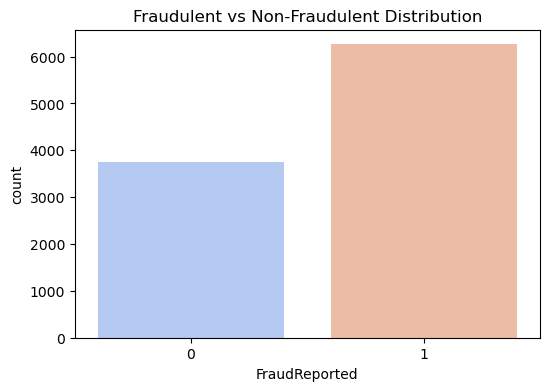

In [10]:
# Step 4: Exploratory Data Analysis (Visualizations)
# Fraud Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='FraudReported', data=data, palette='coolwarm')
plt.title('Fraudulent vs Non-Fraudulent Distribution')
plt.show()

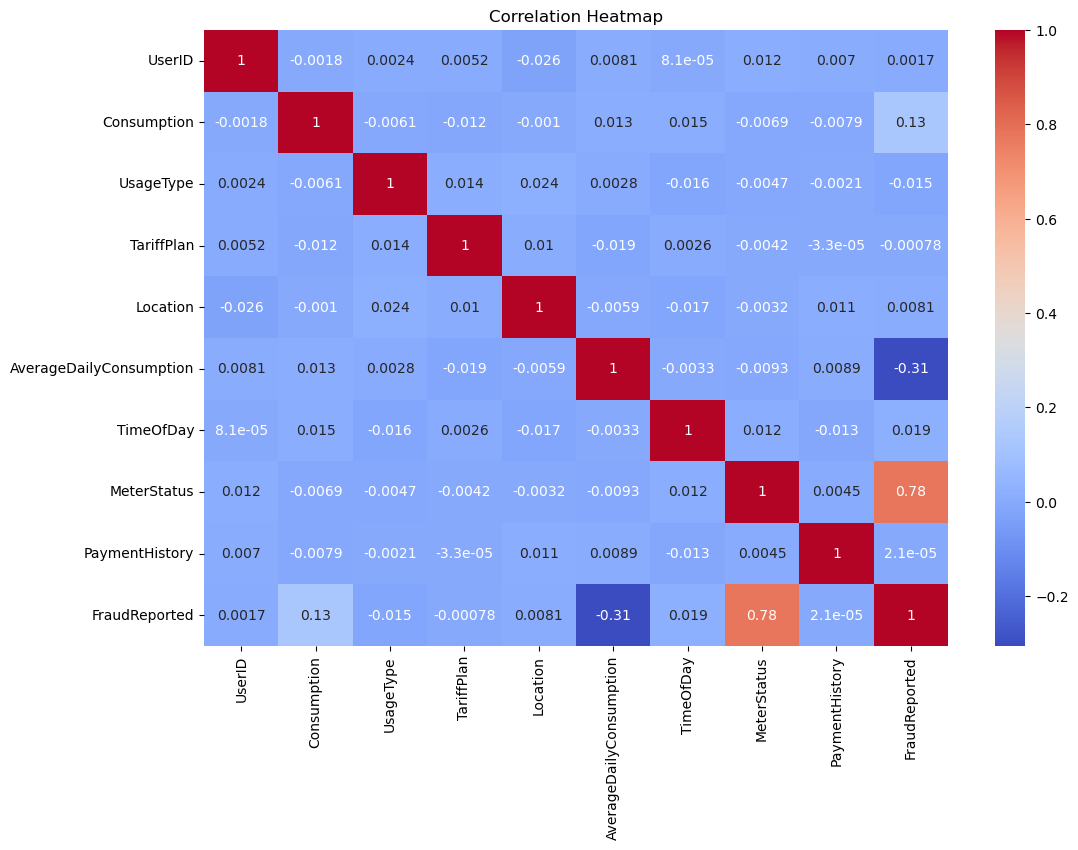

In [11]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

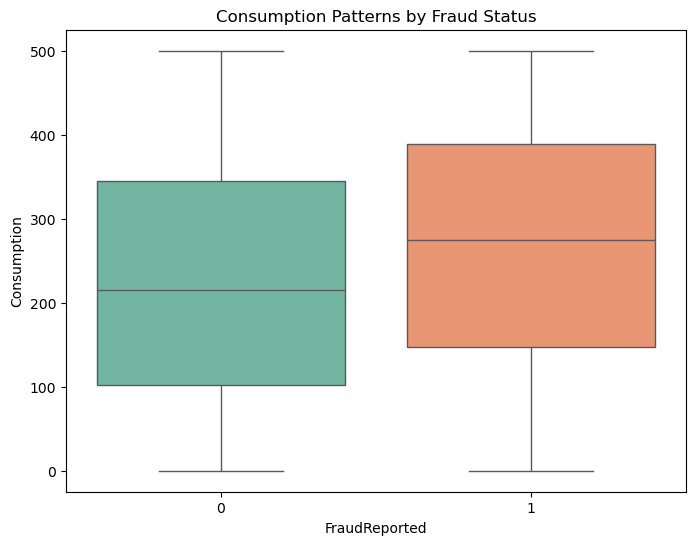

In [12]:
# Boxplot: Consumption by FraudReported
plt.figure(figsize=(8, 6))
sns.boxplot(x='FraudReported', y='Consumption', data=data, palette='Set2')
plt.title('Consumption Patterns by Fraud Status')
plt.show()

In [13]:
# Step 5: Model Building
model = RandomForestClassifier(random_state=42, n_estimators=150, max_depth=12)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, n_estimators=150, random_state=42)

In [14]:
# Step 6: Model Evaluation
# Make predictions
y_pred = model.predict(X_test)

In [15]:
# Step 6: Model Evaluation
# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

Confusion Matrix:
[[1112   10]
 [  20 1858]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1122
           1       0.99      0.99      0.99      1878

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000


Model Accuracy: 99.00%


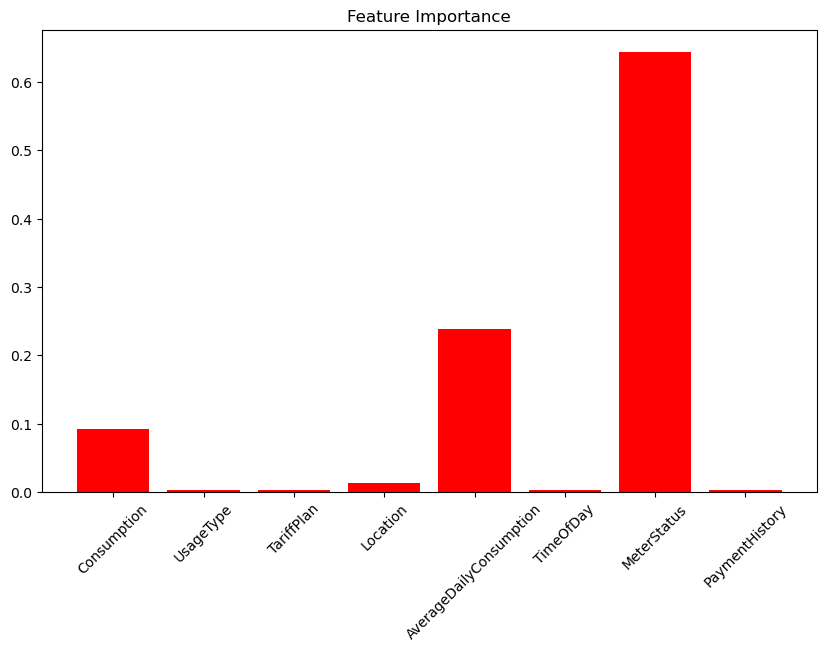

In [16]:
# Step 7: Feature Importance
# Visualize feature importance
feature_importances = model.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(X.columns, feature_importances, color='red')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

In [17]:
import joblib
# Save the model to a file
joblib.dump(model, 'fraud_detection_model.pkl')

['fraud_detection_model.pkl']

In [ ]:
import os
os.system("streamlit run streamlit_app.py")


In [ ]:
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize global variables
data = None
model = None

# Streamlit App
def main():
    global data, model

    # App title
   # Streamlit Custom Styling
st.markdown("""
    <style>
    body {
        background-color: #0f0f0f;
        color: #f5f5f5;
        font-family: 'Poppins', sans-serif;
    }
    .main-title {
        color: #f05454;
        text-align: center;
        font-size: 48px;
        margin-top: 20px;
        margin-bottom: 30px;
    }
    .stButton>button {
        color: white;
        background-color: #ff4b4b;
        border-radius: 8px;
        height: 50px;
        width: 200px;
        font-size: 20px;
    }
    .stButton>button:hover {
        background-color: #ff7878;
        color: black;
        font-weight: bold;
    }
    .sidebar .sidebar-content {
        background-color: #262730;
    }
    </style>
    <h1 class="main-title">⚡ Fraud Detection AI App ⚡</h1>
    """, unsafe_allow_html=True)

    # File uploader
    uploaded_file = st.file_uploader("Upload a CSV file", type=["csv"])

    if uploaded_file is not None:
        try:
            data = pd.read_csv(uploaded_file)
            st.success("Data uploaded successfully!")
            st.dataframe(data.head())
        except Exception as e:
            st.error(f"Error reading the file: {e}")

    # Sidebar for functionalities
    st.sidebar.title("Options")
    action = st.sidebar.selectbox("Choose an action", [
        "None", "Preprocess Data", "Visualize Data", "Train Model", "Make Prediction"
    ])

    if action == "Preprocess Data":
        if data is not None:
            data.dropna(inplace=True)
            st.success("Data preprocessing completed! Missing values removed.")
            st.dataframe(data.head())
        else:
            st.error("No data uploaded!")

    elif action == "Visualize Data":
        if data is not None:
            try:
                st.subheader("Data Visualization")
                sns.pairplot(data)
                st.pyplot(plt)
            except Exception as e:
                st.error(f"Error during visualization: {e}")
        else:
            st.error("No data uploaded!")

    elif action == "Train Model":
        if data is not None:
            try:
                # Split data into features and labels (assuming the last column is the target)
                X = data.iloc[:, :-1]
                y = data.iloc[:, -1]

                # Train-test split
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

                # Train a Random Forest model
                model = RandomForestClassifier(random_state=42)
                model.fit(X_train, y_train)

                # Test the model
                y_pred = model.predict(X_test)
                accuracy = accuracy_score(y_test, y_pred)

                st.success(f"Model trained successfully! Accuracy: {accuracy:.2f}")

                # Display classification report
                st.text("Classification Report:")
                st.text(classification_report(y_test, y_pred))
            except Exception as e:
                st.error(f"Error during model training: {e}")
        else:
            st.error("No data uploaded!")

   elif action == "Make Prediction":
    if model is not None:
        try:
            # User input for prediction
            input_values = st.text_input("Enter feature values separated by commas:", "")

            if st.button("Predict"):
                input_data = [float(val) for val in input_values.split(",")]

                # Check if input length matches features
                if len(input_data) != model.n_features_in_:
                    st.error(f"Expected {model.n_features_in_} features, but got {len(input_data)}")
                else:
                    # Make prediction
                    prediction = model.predict([input_data])

                    # Map prediction result
                    label = 'Fraud' if prediction[0] == 1 else 'No Fraud'
                    st.success(f"Predicted class: {label}")

                    # If fraud detected, show ID(s)
                    if prediction[0] == 1:
                        st.warning("⚠ Fraud Detected! Searching for Fraudulent IDs...")

                        # Find IDs in uploaded data
                        if 'FraudReported' in data.columns:
                            fraud_ids = data[data['FraudReported'] == 1].index.tolist()
                        elif 'Anomaly' in data.columns:
                            fraud_ids = data[data['Anomaly'] == 1].index.tolist()
                        else:
                            fraud_ids = []

                        if fraud_ids:
                            st.info(f"Fraudulent IDs in Uploaded Data: {fraud_ids}")
                        else:
                            st.info("No Fraudulent IDs found in the uploaded dataset.")
        except Exception as e:
            st.error(f"Error during prediction: {e}")
    else:
        st.error("No model trained!")


# Run the app
if __name__ == "__main__":
    main()

In [ ]:
streamlit run "C:\Users\Vishal Rajput\OneDrive\Desktop\Fraud-Detection-Project\streamlit_app.py"